## Validation of model TKA_SHA_JGA_Mo_240503_3 with Gao data

Using evaluation function from script SHA-S-250820

In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import pandas as pd
from ICIW_Plots import cyclers as ICIW_cyclers
plt.style.use(['ICIWstyle'])
import matplotlib

In [2]:
## import the model
from SHA_S_250820 import methanation_equilibrium

In [3]:
## Test the model by verification with data from Gao

## validation (Gao 2012, https://doi.org/10.1039/C2RA00632D)
p = np.array([1*1.01325, 2])*1e5 # p in Pa
T = np.linspace(200 + 273.15, 800 + 273.15, 100) # T in K
gas_type = 'real gas' # choose type of gas from 'ideal gas' and 'real gas'

# Parameter
n0 = np.full((7,),1e-20)
n0[0] = 0.2       # initial mole fraction of CO2
n0[1] = 0.8-7e-20 # initial mole fraction of H2
n0[2] = 1e-20     # initial mole fraction of CH4
n0[3] = 1e-20     # initial mole fraction of H2O
n0[4] = 1e-20     # initial mole fraction of CO
n0[5] = 1e-20     # initial mole fraction of C
n0[6] = 1e-20     # initial mole fraction of Inert

In [4]:
## EQ calculation
results = methanation_equilibrium(T_arr=T,p_arr=p,n0=n0,gas_type=gas_type)

Evaluating methanation equilibrium...

Converged calculations: 97% (97/100)



In [5]:
## data import - validation data
csv_data_Gao = pd.read_csv(
    r'data_Gao_CO2.csv',  # read csv file
    sep = ';')
## convert read data into numpy array
data_Gao = csv_data_Gao.to_numpy()

T_CO2_Gao = data_Gao[:, 0]
x_CO2_Gao = data_Gao[:, 1:7]

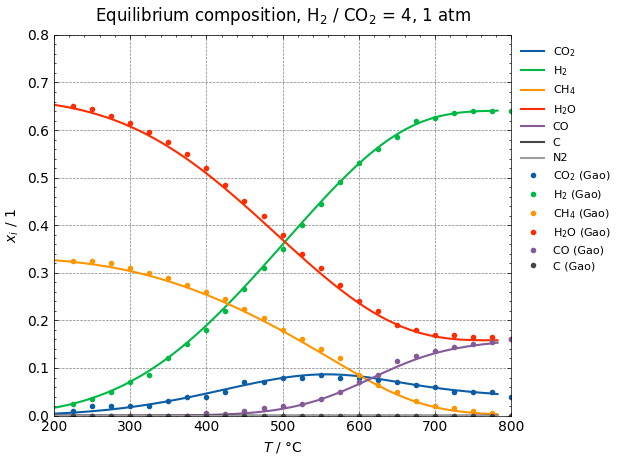

In [6]:
# plt.style.use('ICIWstyle')
font = {'size': 10}
matplotlib.rc('font', **font)

## CO2 methanation
fig, axs = plt.subplots()

res_Gao = results[results['pressure']==p[0]]

axs.plot(T - 273.15,  res_Gao['x_eq_CO2'].values,     '-',                 label = 'CO$_2$')
axs.plot(T - 273.15,  res_Gao['x_eq_H2'].values,     '-',                 label = 'H$_2$')
axs.plot(T - 273.15,  res_Gao['x_eq_CH4'].values,     '-',                 label = 'CH$_4$')
axs.plot(T - 273.15,  res_Gao['x_eq_H2O'].values,     '-',                 label = 'H$_2$O')
axs.plot(T - 273.15,  res_Gao['x_eq_CO'].values,     '-',                 label = 'CO')
axs.plot(T - 273.15,  res_Gao['x_eq_C'].values,     '-',                 label = 'C')
axs.plot(T - 273.15,  res_Gao['x_eq_N2'].values,     '-',                 label = 'N2')
axs.plot(T_CO2_Gao,   x_CO2_Gao[:, 0], 'o', markersize = 3, label = 'CO$_2$ (Gao)')
axs.plot(T_CO2_Gao,   x_CO2_Gao[:, 1], 'o', markersize = 3, label = 'H$_2$ (Gao)')
axs.plot(T_CO2_Gao,   x_CO2_Gao[:, 2], 'o', markersize = 3, label = 'CH$_4$ (Gao)')
axs.plot(T_CO2_Gao,   x_CO2_Gao[:, 3], 'o', markersize = 3, label = 'H$_2$O (Gao)')
axs.plot(T_CO2_Gao,   x_CO2_Gao[:, 4], 'o', markersize = 3, label = 'CO (Gao)')
axs.plot(T_CO2_Gao,   x_CO2_Gao[:, 5], 'o', markersize = 3, label = 'C (Gao)')
axs.set_xlabel('$T$ / °C')
axs.set_ylabel('$x_i$ / 1')
axs.set_title('Equilibrium composition, H$_2$ / CO$_2$ = 4, 1 atm')
axs.set_ylim(0, 0.8)
axs.set_xlim(200, 800)
plt.legend(bbox_to_anchor=(1,1), loc="upper left", fontsize = 8)
plt.tight_layout()
plt.show()

CO methanation conditions

In [15]:
## validation (Gao 2012, https://doi.org/10.1039/C2RA00632D)
p = np.array([1*1.01325,2])*1e5 # p in Pa
T = np.linspace(200 + 273.15, 800 + 273.15, 100) # T in K
gas_type = 'real gas' # choose type of gas from 'ideal gas' and 'real gas'

# Parameter
n0 = np.full((7,),1e-20)
n0[0] = 1e-20       # initial mole fraction of CO2
n0[1] = 0.75-5e-20 # initial mole fraction of H2
n0[2] = 1e-20     # initial mole fraction of CH4
n0[3] = 1e-20     # initial mole fraction of H2O
n0[4] = 0.25     # initial mole fraction of CO
n0[5] = 1e-20     # initial mole fraction of C
n0[6] = 1e-20     # initial mole fraction of Inert

In [16]:
results_CO = methanation_equilibrium(T_arr=T,p_arr=p,n0=n0,gas_type=gas_type)

Evaluating methanation equilibrium...

Converged calculations: 100% (100/100)



In [17]:
## data import - validation data
csv_data_Gao_CO = pd.read_csv(
    r'data_Gao_CO.csv',  # read csv file
    sep = ';')
## convert read data into numpy array
data_Gao_CO = csv_data_Gao_CO.to_numpy()

T_CO_Gao = data_Gao_CO[:, 0]
x_CO_Gao = data_Gao_CO[:, 1:7]

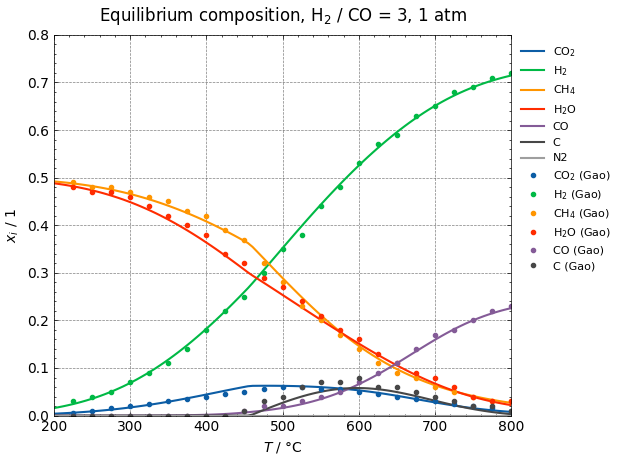

In [18]:
## CO methanation

fig, axs = plt.subplots()

res_1atm = results_CO[results_CO['pressure']==1.01325e5]
axs.plot(T - 273.15,  res_1atm['x_eq_CO2'].values,     '-',                 label = 'CO$_2$')
axs.plot(T - 273.15,  res_1atm['x_eq_H2'].values,     '-',                 label = 'H$_2$')
axs.plot(T - 273.15,  res_1atm['x_eq_CH4'].values,     '-',                 label = 'CH$_4$')
axs.plot(T - 273.15,  res_1atm['x_eq_H2O'].values,     '-',                 label = 'H$_2$O')
axs.plot(T - 273.15,  res_1atm['x_eq_CO'].values,     '-',                 label = 'CO')
axs.plot(T - 273.15,  res_1atm['x_eq_C'].values,     '-',                 label = 'C')
axs.plot(T - 273.15,  res_1atm['x_eq_N2'].values,     '-',                 label = 'N2')
axs.plot(T_CO_Gao,   x_CO_Gao[:, 0], 'o', markersize = 3, label = 'CO$_2$ (Gao)')
axs.plot(T_CO_Gao,   x_CO_Gao[:, 1], 'o', markersize = 3, label = 'H$_2$ (Gao)')
axs.plot(T_CO_Gao,   x_CO_Gao[:, 2], 'o', markersize = 3, label = 'CH$_4$ (Gao)')
axs.plot(T_CO_Gao,   x_CO_Gao[:, 3], 'o', markersize = 3, label = 'H$_2$O (Gao)')
axs.plot(T_CO_Gao,   x_CO_Gao[:, 4], 'o', markersize = 3, label = 'CO (Gao)')
axs.plot(T_CO_Gao,   x_CO_Gao[:, 5], 'o', markersize = 3, label = 'C (Gao)')
axs.set_xlabel('$T$ / °C')
axs.set_ylabel('$x_i$ / 1')
axs.set_title('Equilibrium composition, H$_2$ / CO = 3, 1 atm')
axs.set_ylim(0, 0.8)
axs.set_xlim(200, 800)
plt.legend(bbox_to_anchor=(1,1), loc="upper left", fontsize = 8)
plt.tight_layout()
plt.show()

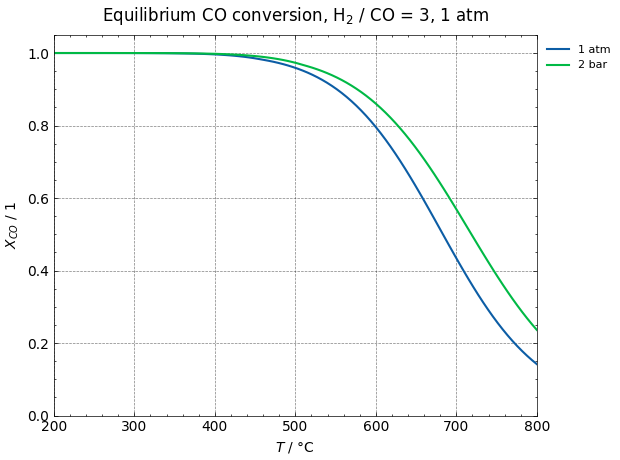

In [21]:
fig, axs = plt.subplots()

res_2bar = results_CO[results_CO['pressure']==2e5]
axs.plot(T - 273.15,  1 - res_1atm['n_eq_CO'].values/res_1atm['n0_CO'],'-',label = '1 atm')
axs.plot(T - 273.15,  1 - res_2bar['n_eq_CO'].values/res_2bar['n0_CO'],'-',label = '2 bar')
axs.set_xlabel('$T$ / °C')
axs.set_ylabel('$X_{CO}$ / 1')
axs.set_title('Equilibrium CO conversion, H$_2$ / CO = 3, 1 atm')
axs.set_ylim(0, 1.05)
axs.set_xlim(200, 800)
plt.legend(bbox_to_anchor=(1,1), loc="upper left", fontsize = 8)
plt.tight_layout()
plt.show()